In [19]:
import pandas as pd
df=pd.read_csv(r"C:\Users\Login\Downloads\final dataset.csv")
df.head()

,Date,Open,High,Low,Close,Shares Traded,Turnover (? Cr)
0,05-Mar-26,24615.95,24854.20,24529.40,24765.90,504339053,40011.88
1,04-Mar-26,24388.80,24602.45,24305.40,24480.50,598993881,47700.19
2,02-Mar-26,24659.25,24989.35,24603.50,24865.70,519228821,41306.37
3,27-Feb-26,25459.85,25476.40,25141.30,25178.65,438924282,38634.68
4,26-Feb-26,25556.30,25572.95,25400.95,25496.55,405219244,33155.50


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2725 entries, 0 to 2724
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             2725 non-null   str    
 1   Open             2725 non-null   float64
 2   High             2725 non-null   float64
 3   Low              2725 non-null   float64
 4   Close            2725 non-null   float64
 5   Shares Traded    2725 non-null   int64  
 6   Turnover (? Cr)  2725 non-null   float64
dtypes: float64(5), int64(1), str(1)
memory usage: 149.2 KB


In [21]:
df.describe()

,Open,High,Low,Close,Shares Traded,Turnover (? Cr)
count,2725.000000,2725.000000,2725.000000,2725.000000,2.725000e+03,2725.000000
mean,14790.778550,14857.313615,14701.953596,14781.106991,3.305051e+08,20947.505413
std,5836.472878,5857.933014,5813.769569,5836.642355,1.839840e+08,10906.804556
min,7023.650000,7034.200000,6825.800000,6970.600000,1.661087e+07,805.890000
25%,9996.550000,10040.750000,9947.000000,9984.800000,2.091878e+08,11461.960000
50%,12108.400000,12137.150000,12023.700000,12073.750000,2.744474e+08,20324.670000
75%,18671.250000,18728.900000,18631.800000,18688.100000,3.918220e+08,27629.710000
max,26333.700000,26373.200000,26210.050000,26328.550000,1.811564e+09,93786.440000


In [22]:
df.columns

Index(['Date ', 'Open ', 'High ', 'Low ', 'Close ', 'Shares Traded ',
       'Turnover (? Cr)'],
      dtype='str')

In [23]:
df.columns = df.columns.str.strip() #here i am basically removing the extra spaces in the name of the columns and trimmin that extra spaces.
print(df.columns)
print(df.isnull().sum())

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Shares Traded',
       'Turnover (? Cr)'],
      dtype='str')
Date               0
Open               0
High               0
Low                0
Close              0
Shares Traded      0
Turnover (? Cr)    0
dtype: int64


In [24]:
df['Date'] = pd.to_datetime(df['Date'], format="%d-%b-%y") #here the date was originally in str format so we converted it into datetime format
df.info() #using info again to check whether the date dtypes is changed from str to datetime or not 

<class 'pandas.DataFrame'>
RangeIndex: 2725 entries, 0 to 2724
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             2725 non-null   datetime64[us]
 1   Open             2725 non-null   float64       
 2   High             2725 non-null   float64       
 3   Low              2725 non-null   float64       
 4   Close            2725 non-null   float64       
 5   Shares Traded    2725 non-null   int64         
 6   Turnover (? Cr)  2725 non-null   float64       
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 149.2 KB


In [25]:
df['Year'] = df['Date'].dt.year  #I created new columns-Year and Month for time-based analysis by separting both years and months to see the changes 
df['Month'] = df['Date'].dt.month
df['Daily Change'] = df['Close'] - df['Open'] #Here, Daily Change represents the difference between closing and opening price indicating profit or loss in a day.
df.head()

,Date,Open,High,Low,Close,Shares Traded,Turnover (? Cr),Year,Month,Daily Change
0,2026-03-05,24615.95,24854.20,24529.40,24765.90,504339053,40011.88,2026,3,149.95
1,2026-03-04,24388.80,24602.45,24305.40,24480.50,598993881,47700.19,2026,3,91.70
2,2026-03-02,24659.25,24989.35,24603.50,24865.70,519228821,41306.37,2026,3,206.45
3,2026-02-27,25459.85,25476.40,25141.30,25178.65,438924282,38634.68,2026,2,-281.20
4,2026-02-26,25556.30,25572.95,25400.95,25496.55,405219244,33155.50,2026,2,-59.75


In [26]:
print("Mean Close:", df['Close'].mean())  
print("Median Close:", df['Close'].median())
print("Minimum Close:", df['Close'].min())
print("Maximum Close:", df['Close'].max())

Mean Close: 14781.106990825687
Median Close: 12073.75
Minimum Close: 6970.6
Maximum Close: 26328.55


In [27]:
print("Mean Daily Change:", df['Daily Change'].mean()) #The negative mean daily change suggests that slightly more days had losses than gains.
print("Max Gain:", df['Daily Change'].max()) #this is the max gain occured in 10 years.
print("Max Loss:", df['Daily Change'].min()) #this is the max loss occured in 10 years.

Mean Daily Change: -9.671559633027545
Max Gain: 847.6000000000004
Max Loss: -1295.0


In [28]:
positive_days = (df['Daily Change'] > 0).sum() #sum of the days where we have gains
negative_days = (df['Daily Change'] < 0).sum() #sum of the days where we have loss
print("Positive Days:", positive_days)
print("Negative Days:", negative_days)

Positive Days: 1265
Negative Days: 1459


In [29]:
top_gains = df.sort_values(by='Daily Change', ascending=False).head(5)
print(top_gains[['Date', 'Daily Change']]) #the tops 5 days when we had the highest profit in given timeline 

           Date  Daily Change
1483 2020-03-13         847.6
1475 2020-03-25         582.7
1602 2019-09-20         527.4
1262 2021-02-01         522.6
205  2025-05-12         504.6


In [30]:
top_losses = df.sort_values(by='Daily Change').head(5)
print(top_losses[['Date', 'Daily Change']]) #the biggest 5 losses correspond to market crashes

           Date  Daily Change
436  2024-06-04      -1295.00
1480 2020-03-18       -619.65
21   2026-02-03       -580.50
23   2026-02-01       -508.30
524  2024-01-23       -477.90


In [31]:
yearly_avg = df.groupby('Year')['Close'].mean() #The yearly average closing price shows long-term market growth.
print(yearly_avg)

Year
2015     8206.617157
2016     8092.193927
2017     9590.717944
2018    10749.392276
2019    11432.632245
2020    11161.474802
2021    16026.760685
2022    17245.430444
2023    18903.131707
2024    23482.061089
2025    24575.608032
2026    25557.006818
Name: Close, dtype: float64


In [32]:
monthly_avg = df.groupby('Month')['Close'].mean()
print(monthly_avg) #grouping every month from 2015-2026 and then calculating avg .

Month
1     15478.543404
2     15529.568100
3     13727.082207
4     13905.303382
5     14026.174678
6     14199.493750
7     14717.474792
8     14770.530349
9     15215.116814
10    15191.376682
11    15098.949099
12    15437.989362
Name: Close, dtype: float64


In [33]:
print("Fluctuation(Std Dev of Close):", df['Close'].std()) #here flucutuation means that how much up down happening in market and how far is price going from mean

Fluctuation(Std Dev of Close): 5836.642355054537


In [34]:
print(df[['Open','High','Low','Close']].corr())
print("\nMore meaningful — Daily Change vs Volume:") # useful correlation
print(df[['Daily Change', 'Shares Traded']].corr()) #shares traded means how much shares(quantity) bought/sold that day
#All price variables (Open, High, Low, Close) are highly correlated (~0.99), indicating strong linear relationships in stock prices.

           Open      High       Low     Close
Open   1.000000  0.999922  0.999881  0.999800
High   0.999922  1.000000  0.999855  0.999906
Low    0.999881  0.999855  1.000000  0.999910
Close  0.999800  0.999906  0.999910  1.000000

More meaningful — Daily Change vs Volume:
               Daily Change  Shares Traded
Daily Change       1.000000      -0.035569
Shares Traded     -0.035569       1.000000


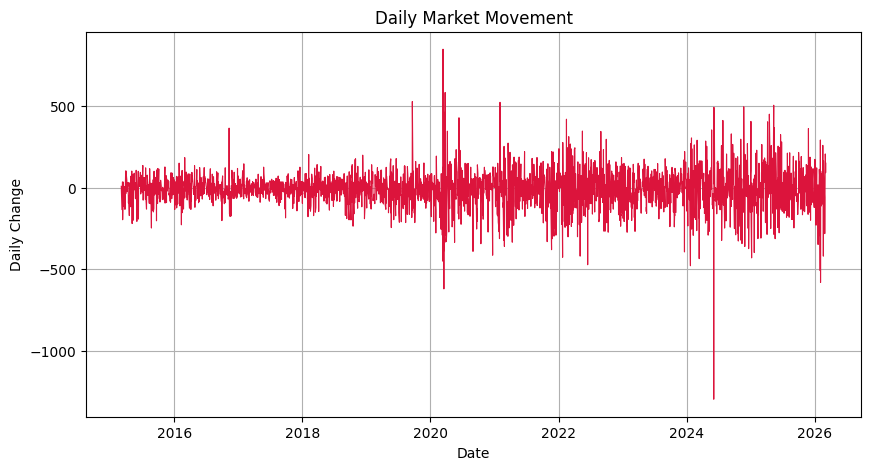

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Daily Change'],color='crimson', linewidth=0.8)
plt.xlabel("Date")
plt.ylabel("Daily Change")
plt.title("Daily Market Movement")
plt.grid()
plt.savefig("daily_market_movement.png", dpi=300, bbox_inches="tight")
plt.show()
#Daily changes fluctuate around zero, with occasional spikes indicating high volatility periods especially during covid crisis.

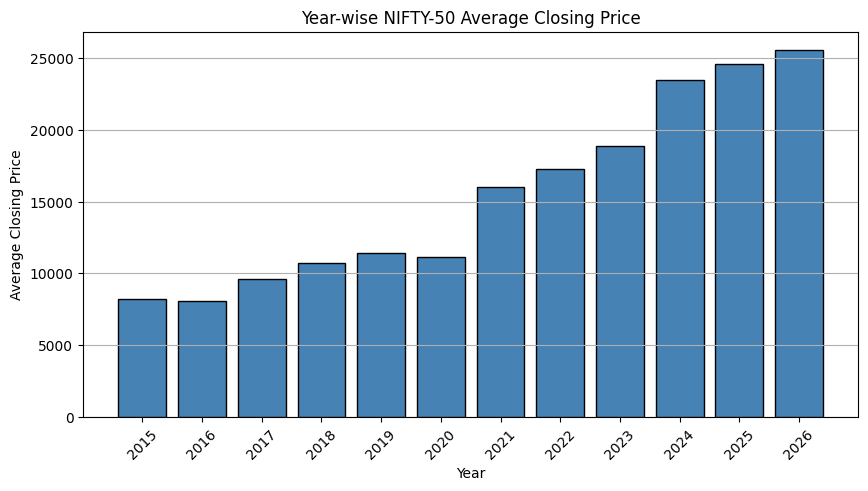

In [36]:
yearly_avg = df.groupby('Year')['Close'].mean()
plt.figure(figsize=(10,5))
plt.bar(yearly_avg.index, yearly_avg.values, 
        color='steelblue', edgecolor='black')
plt.xlabel("Year")
plt.ylabel("Average Closing Price")
plt.title("Year-wise NIFTY-50 Average Closing Price")
plt.xticks(yearly_avg.index, rotation=45)
plt.grid(axis='y')
plt.show()
# Steady growth every year except 2016 and 2020 dip
#The bar chart clearly shows steady growth in market value over the years.

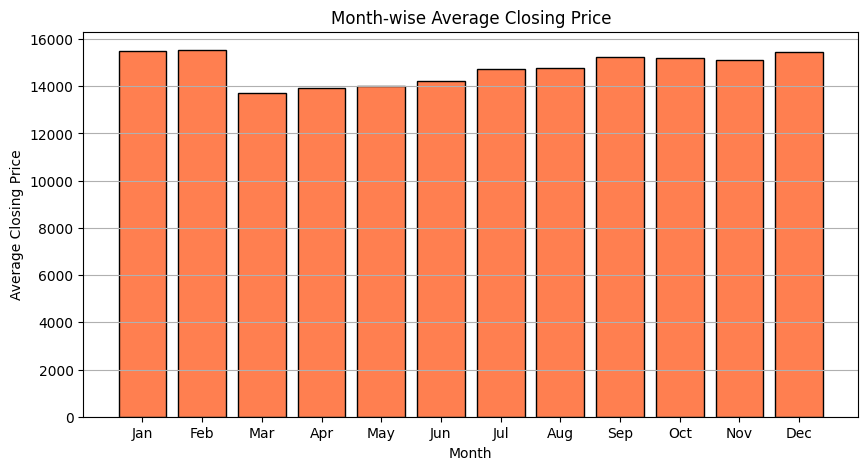

In [37]:
monthly_avg = df.groupby('Month')['Close'].mean()
months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']
plt.figure(figsize=(10,5))
plt.bar(months, monthly_avg.values,
        color='coral', edgecolor='black')
plt.xlabel("Month")
plt.ylabel("Average Closing Price")
plt.title("Month-wise Average Closing Price")
plt.grid(axis='y')
plt.show()


# Jan and Feb show higher averages, March dips due to year-end corrections
#Monthly trends do not show extreme variation, indicating consistent market behavior.

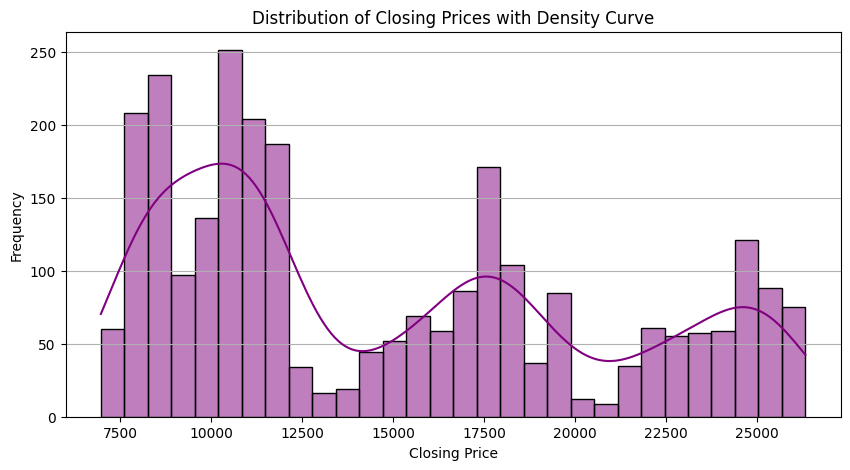

In [38]:
import seaborn as sns
plt.figure(figsize=(10,5))
sns.histplot(df['Close'], bins=30, color='purple', edgecolor='black', kde=True)
plt.xlabel("Closing Price")
plt.ylabel("Frequency")
plt.title("Distribution of Closing Prices with Density Curve")
plt.grid(axis='y')
plt.savefig("closing_price_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

#The distribution of closing prices shows multiple peaks, reflecting different market phases over time.

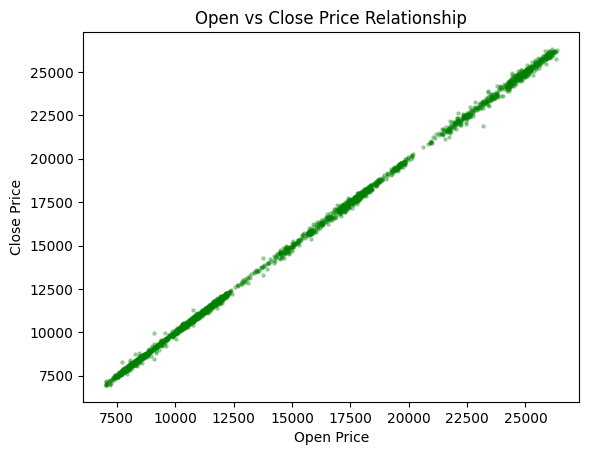

In [39]:
plt.figure()
plt.scatter(df['Open'], df['Close'], color='green', alpha=0.3, s=5)
plt.xlabel("Open Price")
plt.ylabel("Close Price")
plt.title("Open vs Close Price Relationship")
plt.show()
#The strong linear pattern confirms high correlation between opening and closing prices.

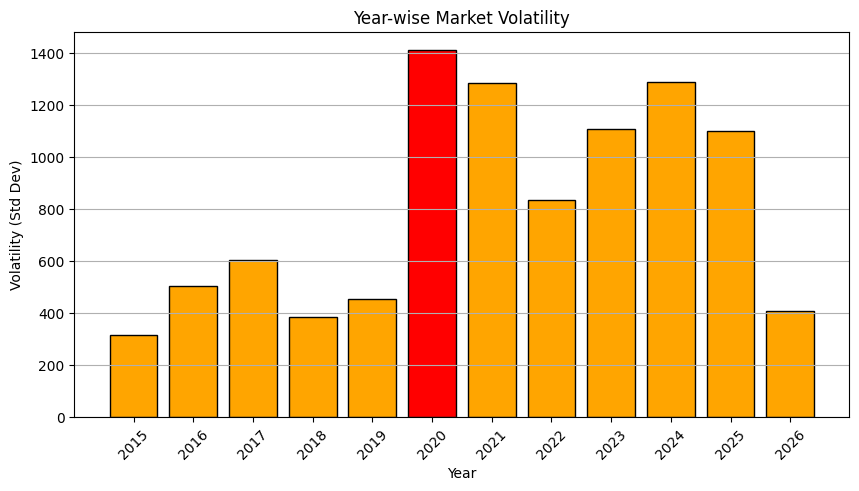

In [40]:
yearly_volatility = df.groupby('Year')['Close'].std()
colors = ['red' if y == 2020 else 'orange' for y in yearly_volatility.index]
plt.figure(figsize=(10,5))
plt.bar(yearly_volatility.index, yearly_volatility.values,
        color=colors, edgecolor='black')
plt.xlabel("Year")
plt.ylabel("Volatility (Std Dev)")
plt.title("Year-wise Market Volatility")
plt.xticks(yearly_volatility.index, rotation=45)
plt.grid(axis='y')
plt.show()
# 2020 highlighted in red showing highest volatility due to COVID-19 pandemic
#Volatility is highest during crisis periods(like 2020 covid pandemic)

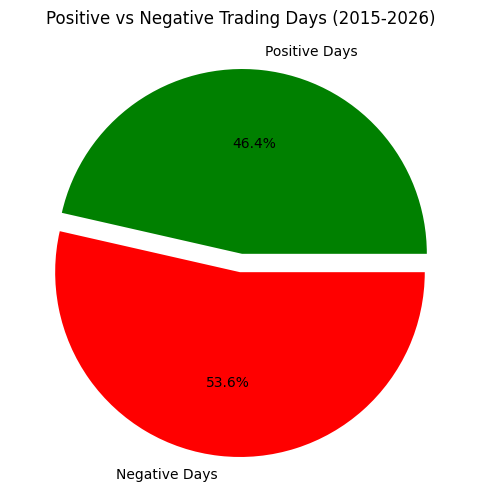

In [41]:
plt.figure(figsize=(6,6))
plt.pie([positive_days, negative_days],
        labels=['Positive Days', 'Negative Days'],
        autopct='%1.1f%%',
        colors=['green', 'red'],
        explode=(0.05, 0.05))
plt.title("Positive vs Negative Trading Days (2015-2026)")
plt.savefig("pie_chart.png", dpi=300, bbox_inches="tight")
plt.show()
# 46.4% positive vs 53.6% negative daysl (More negative days than positive)

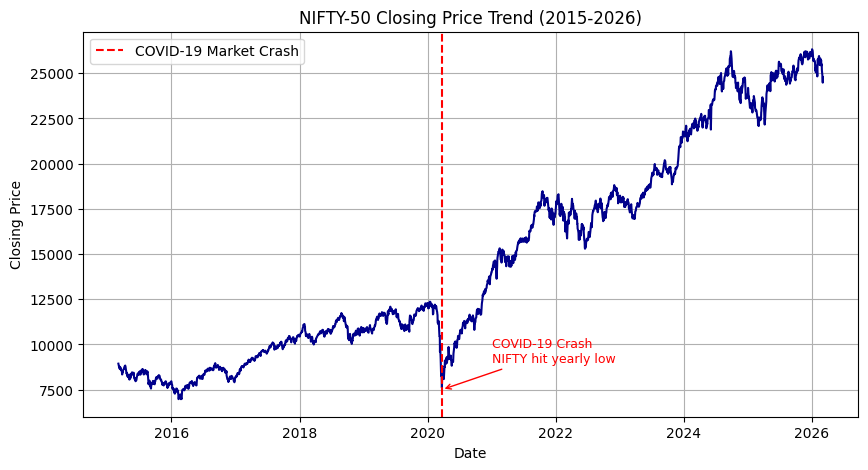

In [42]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Close'], color='darkblue', linewidth=1.5)

# COVID Crash Reference Line
plt.axvline(pd.Timestamp('2020-03-23'), color='red', 
            linestyle='--', linewidth=1.5, label='COVID-19 Market Crash')

plt.annotate('COVID-19 Crash\nNIFTY hit yearly low', 
             xy=(pd.Timestamp('2020-03-23'), 7500),
             xytext=(pd.Timestamp('2021-01-01'), 9000),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=9, color='red') #The closing price shows a strong upward trend over time, with noticeable dips during market crises such as 2020.

plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.title("NIFTY-50 Closing Price Trend (2015-2026)")
plt.legend()
plt.grid()
plt.show()


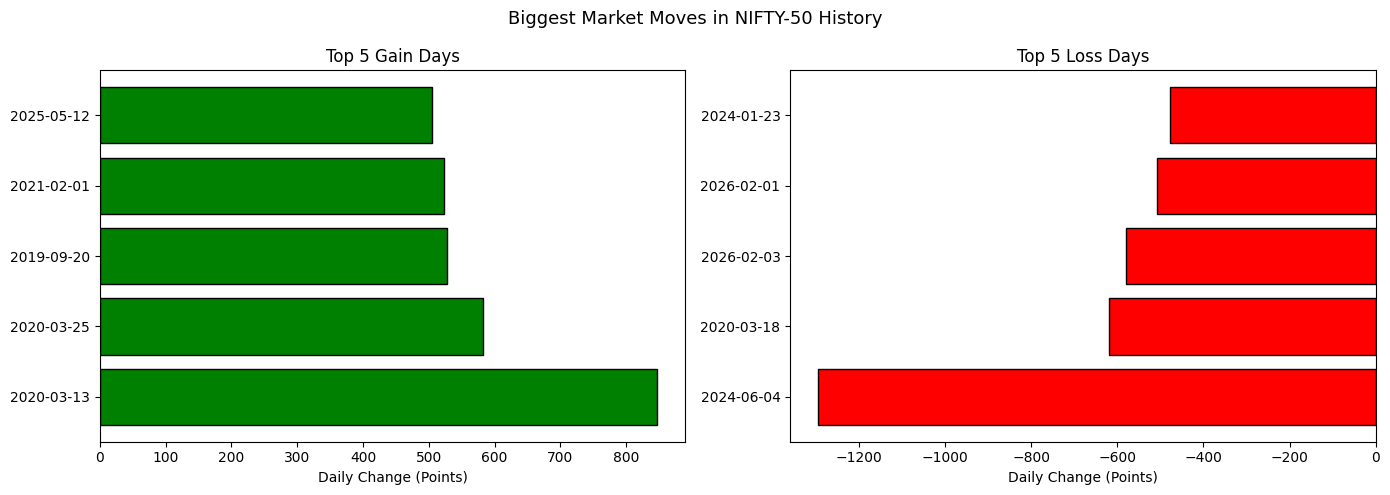

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Top 5 Gains
top_gains = df.sort_values('Daily Change', ascending=False).head(5)
axes[0].barh(top_gains['Date'].astype(str), top_gains['Daily Change'],
             color='green', edgecolor='black')
axes[0].set_title("Top 5 Gain Days")
axes[0].set_xlabel("Daily Change (Points)")

# Top 5 Losses
top_losses = df.sort_values('Daily Change').head(5)
axes[1].barh(top_losses['Date'].astype(str), top_losses['Daily Change'],
             color='red', edgecolor='black')
axes[1].set_title("Top 5 Loss Days")
axes[1].set_xlabel("Daily Change (Points)")

plt.suptitle("Biggest Market Moves in NIFTY-50 History", fontsize=13)
plt.tight_layout()
plt.show()



# Most extreme moves happened during COVID-19 (2020) and election results (2024)

In [66]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
# Creating a day number column (1, 2, 3... for each trading day)
df = df.sort_values('Date').reset_index(drop=True) #sorting the data according to date
df['Day_Number'] = range(1, len(df) + 1)
print("Data prepared for regression model")
print(df[['Date', 'Day_Number', 'Close']].head())

Data prepared for regression model
        Date  Day_Number    Close
0 2015-03-05           1  8937.75
1 2015-03-09           2  8756.75
2 2015-03-10           3  8712.05
3 2015-03-11           4  8699.95
4 2015-03-12           5  8776.00


In [67]:
# X = input feature, y = what we want to predict independent variables
X = df[['Day_Number']] # Feature (independent variables )
y = df['Close'] # Target (dependent variable)
# Split data - 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.2, random_state=42)
# Train the model
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained successfully!")
print(f"Total training samples: {len(X_train)}")
print(f"Total testing samples: {len(X_test)}")
# RMSE tells us the average prediction error, while R² tells how well the model explains the data. In my project, RMSE is high (~1700), meaning predictions are not very accurate, even though R² is high due to time-based correlation

Model trained successfully!
Total training samples: 2180
Total testing samples: 545


In [68]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred)) #avg of error is rmse 
r2   = r2_score(y_test, y_pred)

print("Model Evaluation:")
print(f"R² Score    : {r2:.4f}")  #accuracy 
print(f"RMSE        : {rmse:.2f} points")
print(f"Model Slope : {model.coef_[0]:.4f} (points gained per trading day on average)") #slope

"""
The high R² does NOT mean this model is accurate for real prediction.
It occurs because both 'Day_Number' and 'Close' increase over time —
a spurious correlation. RMSE of ~1700 points means predictions can be
off by ₹1700 on average, which is a large error.
This model captures the long-term trend, not short-term price movements.
"""

Model Evaluation:
R² Score    : 0.9125
RMSE        : 1703.10 points
Model Slope : 7.1087 (points gained per trading day on average)


"\nThe high R² does NOT mean this model is accurate for real prediction.\nIt occurs because both 'Day_Number' and 'Close' increase over time —\na spurious correlation. RMSE of ~1700 points means predictions can be\noff by ₹1700 on average, which is a large error.\nThis model captures the long-term trend, not short-term price movements.\n"

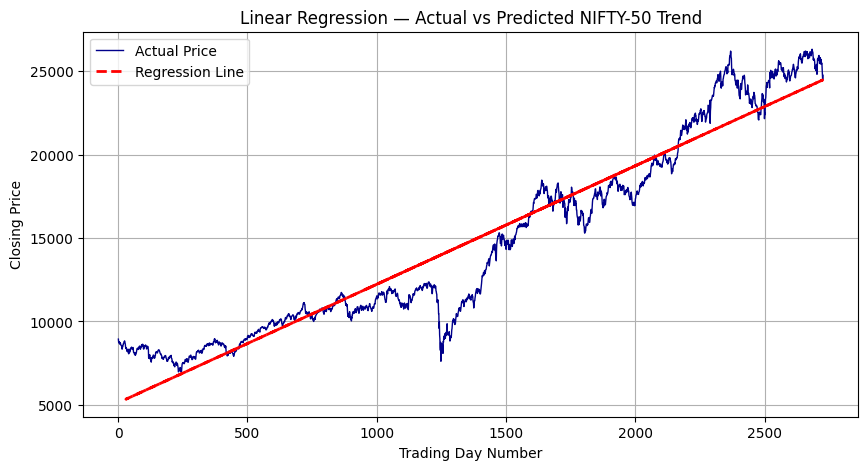

In [69]:
plt.figure(figsize=(10,5))

# Actual closing prices
plt.plot(df['Day_Number'], df['Close'], 
         color='darkblue', linewidth=1, label='Actual Price')

# Regression line (predicted trend)
plt.plot(X_test, y_pred, 
         color='red', linewidth=2, 
         linestyle='--', label='Regression Line')

plt.xlabel("Trading Day Number")
plt.ylabel("Closing Price")
plt.title("Linear Regression — Actual vs Predicted NIFTY-50 Trend")
plt.legend()
plt.grid()
plt.show()
# This graph shows that the regression model captures the overall upward trend of the market, but fails to capture short-term fluctuations and volatility

In [70]:
# Predict what closing price might look like on day 3000
future_day = pd.DataFrame([[3000]], columns=['Day_Number'])
predicted_price = model.predict(future_day)

print(f"Predicted Closing Price for Trading Day 3000: ₹{predicted_price[0]:.2f}")
# This gives a rough estimate based on historical trend


Predicted Closing Price for Trading Day 3000: ₹26446.02


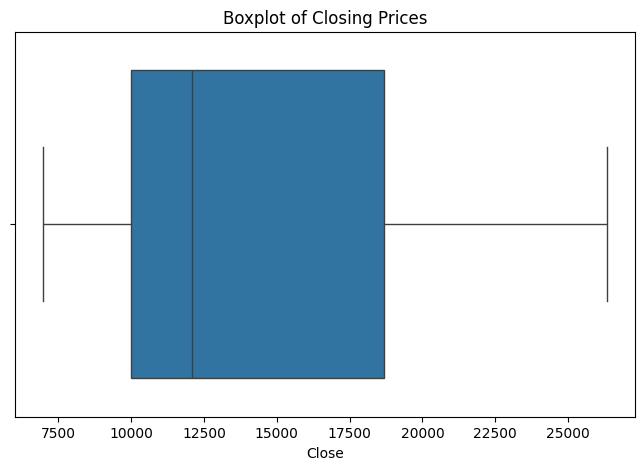

In [49]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x=df['Close'])
plt.title("Boxplot of Closing Prices")
plt.show()

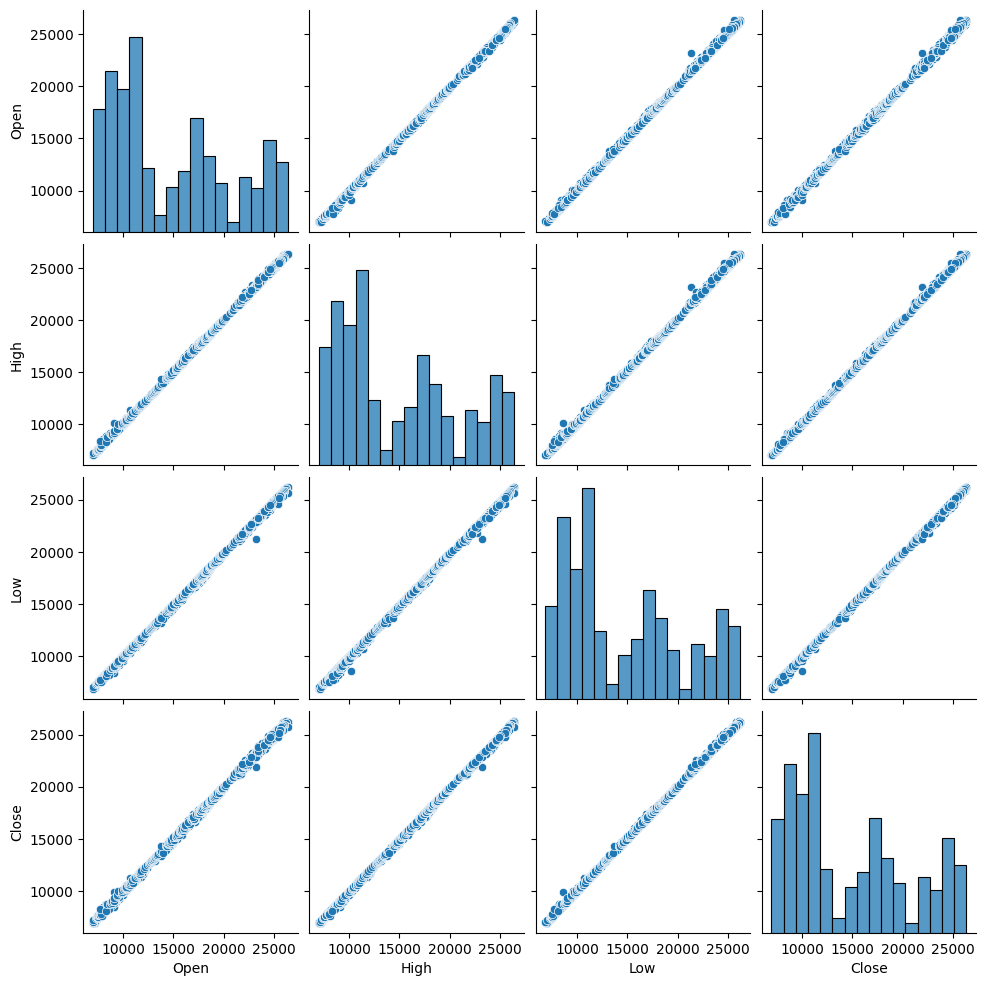

In [50]:
sns.pairplot(df[['Open','High','Low','Close']])
plt.savefig("pair_plot.png", dpi=300, bbox_inches="tight")
plt.show() #paiplot 

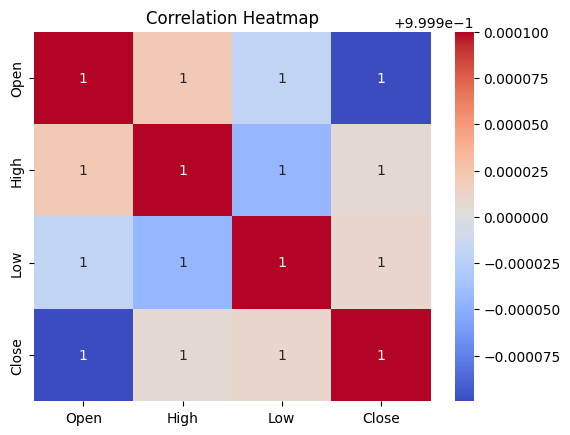

In [51]:
sns.heatmap(df[['Open','High','Low','Close']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show() #heat map

In [72]:
# SECOND MODEL (DECISION TREE)
from sklearn.tree import DecisionTreeRegressor
# Create and train model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
# Predictions
y_pred_dt = dt_model.predict(X_test)
#basically DT divides every thing into part and assign values in every avg accordingly

In [73]:
# MODEL COMPARISON
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
print("\nMODEL COMPARISON")
# Linear Regression Results
print("\nLinear Regression:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))
# Decision Tree Results
print("\nDecision Tree:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("R2 Score:", r2_score(y_test, y_pred_dt))


MODEL COMPARISON

Linear Regression:
RMSE: 1703.098920228987
R2 Score: 0.912534309701985

Decision Tree:
RMSE: 142.21211652723542
R2 Score: 0.9993901385515637


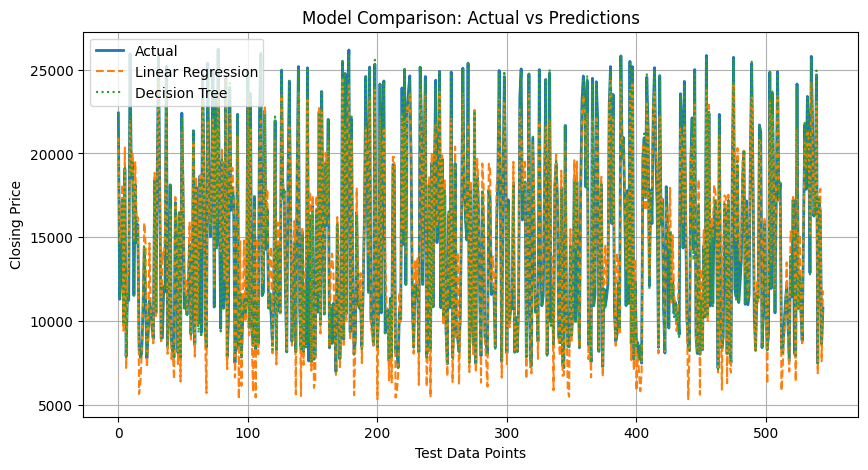

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test.values, label='Actual', linewidth=2)
plt.plot(y_pred, label='Linear Regression', linestyle='--')
plt.plot(y_pred_dt, label='Decision Tree', linestyle=':')

plt.title("Model Comparison: Actual vs Predictions")
plt.xlabel("Test Data Points")
plt.ylabel("Closing Price")
plt.legend()
plt.grid()
plt.savefig("model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
# The Decision Tree model closely follows the actual data, indicating possible overfitting, while Linear Regression captures the overall trend but fails to model short-term fluctuations

In [55]:
# Linear Regression captures the overall trend but fails to model short-term fluctuations. Decision Tree closely fits the training data, which leads to overfitting and poor generalization on unseen data.